In [1]:
#1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#2
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score
)
from sklearn.preprocessing import label_binarize

In [3]:
#3
DATASET_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Wheat varieties dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3

In [4]:
#4
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())

Found 900 images belonging to 3 classes.
Found 224 images belonging to 3 classes.


In [5]:
#5
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Loaded pre-trained ResNet50 (without top)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freezeed base layers
for layer in base_model.layers:
    layer.trainable = False

# Customized classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
#6
start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

training_time = time.time() - start_time
print("Training time (sec):", training_time)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 330s 11s/step - accuracy: 0.3517 - loss: 1.3435 - val_accuracy: 0.3348 - val_loss: 1.1056
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.3575 - loss: 1.2353 - val_accuracy: 0.3393 - val_loss: 1.1001
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - accuracy: 0.3340 - loss: 1.2733 - val_accuracy: 0.3304 - val_loss: 1.1025
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.3638 - loss: 1.1751 - val_accuracy: 0.3750 - val_loss: 1.0975
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.3603 - loss: 1.1637 - val_accuracy: 0.3705 - val_loss: 1.0987
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.3646 - loss: 1.1497 - val_accuracy: 0.3839 - val_loss: 1.0984
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.3892 - loss: 1.1073 - val_accuracy: 0.3661 - val_loss: 1.1017
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - accuracy: 0.3614 - loss: 1.1132 - val_accuracy: 0.

In [7]:
#7
y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step


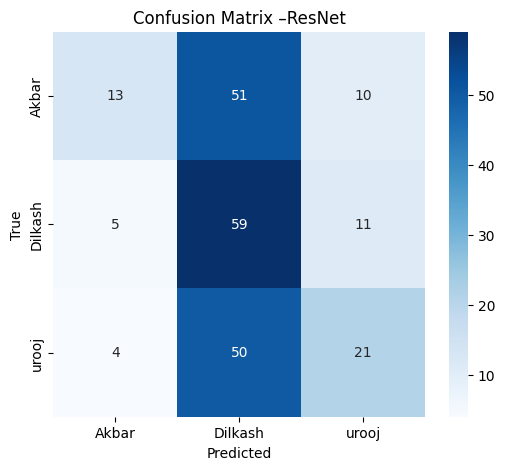

Class Akbar Accuracy: 0.1757
Class Dilkash Accuracy: 0.7867
Class urooj Accuracy: 0.2800


In [8]:
#8
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix –ResNet")
plt.show()

class_acc = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(class_acc):
    print(f"Class {class_names[i]} Accuracy: {acc:.4f}")

In [10]:
#9
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

       Akbar       0.59      0.18      0.27        74
     Dilkash       0.37      0.79      0.50        75
       urooj       0.50      0.28      0.36        75

    accuracy                           0.42       224
   macro avg       0.49      0.41      0.38       224
weighted avg       0.49      0.42      0.38       224



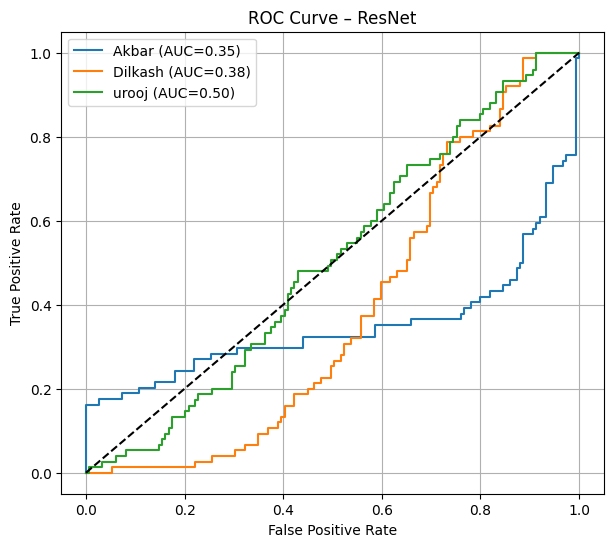

In [11]:
#10
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – ResNet")
plt.legend()
plt.grid()
plt.show()

In [12]:
# 11 — Saved evaluation results (ResNet)

import time

start_time = time.time()

# Evaluate on validation data
val_loss, val_accuracy = model.evaluate(val_data, verbose=1)

evaluation_time = time.time() - start_time

print("Validation Accuracy:", val_accuracy)
print("Evaluation Time (sec):", evaluation_time)

# Save results in a dictionary (used later for summary table)
resnet_results = {
    "Model": "ResNet50",
    "Accuracy": val_accuracy,
    "Evaluation Time (sec)": evaluation_time
}

resnet_results

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.3582 - loss: 1.2462
Validation Accuracy: 0.4151785671710968
Evaluation Time (sec): 1.3799355030059814


{'Model': 'ResNet50',
 'Accuracy': 0.4151785671710968,
 'Evaluation Time (sec)': 1.3799355030059814}

In [16]:
#12
import numpy as np
import pandas as pd
import os
from sklearn.metrics import classification_report

SAVE_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Task2_Results"
os.makedirs(SAVE_PATH, exist_ok=True)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = val_data.classes

# 1 = correct, 0 = wrong (needed for paired t-test)
correct_array = (y_pred_classes == y_true_classes).astype(int)

#CHANGED model name accordingly
MODEL_NAME = "resnet"

np.save(f"{SAVE_PATH}/{MODEL_NAME}_correct.npy", correct_array)

# Get classification report as dictionary
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Extract metrics
precision = report_dict['macro avg']['precision']
recall = report_dict['macro avg']['recall']
f1 = report_dict['macro avg']['f1-score']

# Save metrics
metrics_df = pd.DataFrame({
    "Accuracy": [val_accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "AUC": [np.mean(list(roc_auc.values()))],
    "Training Time (sec)": [training_time]
})

metrics_df.to_csv(f"{SAVE_PATH}/{MODEL_NAME}_metrics.csv", index=False)

print("Saved results for", MODEL_NAME)


Saved results for resnet
